# TD 4 — Préparation pour la modélisation, ACP et clustering (chapitres 8–9)

**Cours : Analyse et traitement des données** · Auteur : *Issa Gueye*

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, silhouette_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA = next(p for p in [Path("data/brutes"), Path("../data/brutes"), Path("../../data/brutes")] if p.exists())
menages = pd.read_csv(DATA / "enquete_menages.csv")
menages.loc[menages["taille_menage"] == 99, "taille_menage"] = np.nan

## Exercice 1 ⭐ — Encodage
Encodez `milieu`, `region` et `education_chef` de `menages` : lesquelles en one-hot, laquelle en ordinal ? Pourquoi ?
Réalisez l'encodage avec `pd.get_dummies` pour les nominales et un dictionnaire pour l'ordinale.

In [2]:
# milieu et region sont nominales -> one-hot ; education_chef est ordinale -> codes ordonnés.
enc = pd.get_dummies(menages[["milieu", "region"]], drop_first=True, dtype=int)
enc["education_ord"] = menages["education_chef"].map({"Aucun": 0, "Coranique": 1, "Primaire": 2, "Secondaire": 3, "Supérieur": 4})
enc.head()

,milieu_Urbain,region_Diourbel,region_Kaolack,region_Louga,region_Saint-Louis,region_Tambacounda,region_Thiès,region_Ziguinchor,education_ord
0,0,1,0,0,0,0,0,0,0
1,1,0,0,0,0,0,1,0,2
2,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,2
4,1,0,0,0,0,0,0,0,4


## Exercice 2 ⭐⭐ — Créer des variables
Créez : `log_revenu`, `revenu_par_personne`, `taux_epargne = 1 - depenses/revenu`, et un indicateur `revenu_manquant`.
Calculez la corrélation de Spearman entre `revenu_par_personne` et `taille_menage`. Commentez.

In [3]:
f = menages.assign(
    log_revenu=np.log(menages["revenu_mensuel_fcfa"]),
    revenu_par_personne=menages["revenu_mensuel_fcfa"] / menages["taille_menage"],
    taux_epargne=1 - menages["depenses_mensuelles_fcfa"] / menages["revenu_mensuel_fcfa"],
    revenu_manquant=menages["revenu_mensuel_fcfa"].isna().astype(int),
)
print(f[["revenu_par_personne", "taille_menage"]].corr(method="spearman").round(3))
# Corrélation négative modérée (ρ ≈ −0,5) : le revenu total croît peu avec la taille, donc le revenu par personne baisse quand
# le ménage s'agrandit — information que le revenu brut ne montrait pas.

                     revenu_par_personne  taille_menage
revenu_par_personne                1.000         -0.515
taille_menage                     -0.515          1.000


## Exercice 3 ⭐⭐⭐ — Fuite de données
Un collègue standardise `X` puis fait `train_test_split`, et ajoute la variable `depenses_mensuelles_fcfa` pour prédire
le revenu. Identifiez **deux** problèmes potentiels de fuite / de validité, puis écrivez un pipeline correct qui prédit
`log(revenu)` à partir de `milieu`, `region`, `education_chef`, `taille_menage`, `age_chef`, `acces_internet`
(sans les dépenses). Donnez le R² et la MAE (en FCFA) sur le test.

In [4]:
# 1) Standardiser avant de séparer : moyenne/écart-type appris en partie sur le test -> légère fuite.
# 2) Les dépenses sont mesurées en même temps que le revenu et quasi-proportionnelles à lui : si elles ne sont pas
#    disponibles au moment de la prédiction (cas d'usage réel), la performance obtenue est illusoire.
d = menages.dropna(subset=["revenu_mensuel_fcfa"])
X = d[["milieu", "region", "education_chef", "taille_menage", "age_chef", "acces_internet"]]
y = np.log(d["revenu_mensuel_fcfa"])
prep = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), ["taille_menage", "age_chef"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["milieu", "region", "education_chef", "acces_internet"]),
])
modele = make_pipeline(prep, LinearRegression())
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)
modele.fit(X_tr, y_tr)
pred = modele.predict(X_te)
print(f"R² (log) = {r2_score(y_te, pred):.3f} | MAE = {mean_absolute_error(np.exp(y_te), np.exp(pred)):,.0f} FCFA")

R² (log) = 0.312 | MAE = 113,503 FCFA


## Exercice 4 ⭐⭐ — ACP à la main
Sur les 4 variables numériques de `resultats_etudiants.csv` (heures, contrôle continu, examen, et une variable
`bruit` aléatoire que vous ajoutez) :
1. standardisez, calculez la matrice de corrélation et ses valeurs/vecteurs propres avec `np.linalg.eigh` ;
2. vérifiez que vous retrouvez `PCA().explained_variance_ratio_` ;
3. interprétez la première composante. Où se place la variable `bruit` ?

In [5]:
etu = pd.read_csv(DATA / "resultats_etudiants.csv")
rng = np.random.default_rng(1)
V = etu[["heures_etude_semaine", "note_controle_continu", "note_examen"]].assign(bruit=rng.normal(size=len(etu)))
Z = StandardScaler().fit_transform(V)
vals, vecs = np.linalg.eigh(np.corrcoef(Z, rowvar=False))
vals, vecs = vals[::-1], vecs[:, ::-1]
print("à la main :", (vals / vals.sum()).round(4))
print("sklearn   :", PCA().fit(Z).explained_variance_ratio_.round(4))
print(pd.DataFrame(vecs[:, :2], index=V.columns, columns=["CP1", "CP2"]).round(3))
# CP1 (≈ 39 %) = axe « réussite scolaire » : les deux notes y ont des poids forts et de même signe (le signe global
# d'une composante est arbitraire). Les heures d'étude, peu corrélées aux notes, portent surtout CP2.
# La variable bruit est mal représentée dans le plan CP1–CP2 : elle se retrouve sur les composantes suivantes.
# Remarquez que CP2 et CP3 ont presque la même variance (≈ 25 %) : leur interprétation séparée est instable.

à la main : [0.3863 0.2626 0.2488 0.1023]
sklearn   : [0.3863 0.2626 0.2488 0.1023]
                         CP1    CP2
heures_etude_semaine  -0.170  0.903
note_controle_continu -0.674 -0.335
note_examen           -0.717  0.084
bruit                 -0.047  0.254


## Exercice 5 ⭐⭐ — k-means sur données simulées
Générez 3 groupes gaussiens 2D (`sklearn.datasets.make_blobs`, `random_state=3`) puis :
1. appliquez k-means pour k = 2 à 6 et tracez l'inertie et la silhouette ;
2. **sans** standardiser, multipliez la 1ʳᵉ coordonnée par 100 et refaites k-means (k=3). Que se passe-t-il ? Pourquoi ?

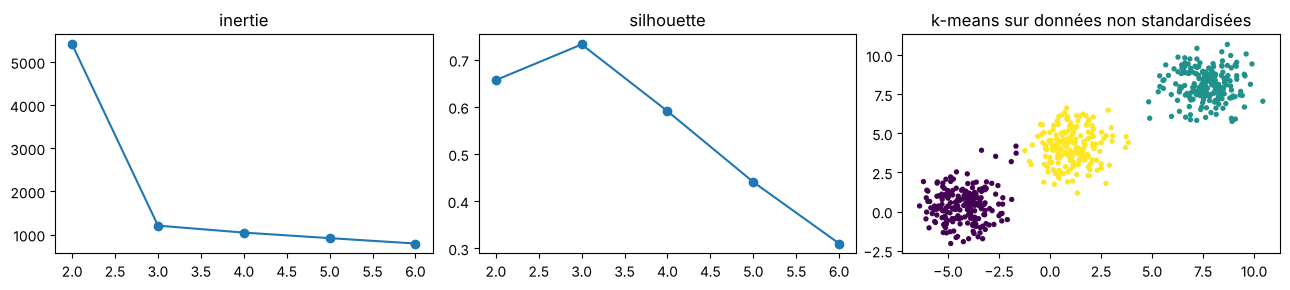

In [6]:
from sklearn.datasets import make_blobs

Xb, yb = make_blobs(n_samples=600, centers=3, random_state=3)
ks = range(2, 7)
iner = [KMeans(k, n_init=10, random_state=0).fit(Xb).inertia_ for k in ks]
sil = [silhouette_score(Xb, KMeans(k, n_init=10, random_state=0).fit_predict(Xb)) for k in ks]
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].plot(ks, iner, "o-"); ax[0].set_title("inertie"); ax[1].plot(ks, sil, "o-"); ax[1].set_title("silhouette")
Xd = Xb * np.array([100, 1])
lab = KMeans(3, n_init=10, random_state=0).fit_predict(Xd)
ax[2].scatter(Xb[:, 0], Xb[:, 1], c=lab, s=8); ax[2].set_title("k-means sur données non standardisées")
plt.tight_layout(); plt.show()
# La distance euclidienne est dominée par la coordonnée multipliée par 100 : les groupes sont découpés seulement
# selon x. D'où la règle : standardiser avant k-means quand les unités diffèrent.

## Exercice 6 ⭐⭐⭐ — Segmentation des ménages
Segmentez les ménages (variables : log revenu, log dépenses, taille, âge du chef, indicatrices électricité/internet/
mobile money) avec un pipeline `imputation → standardisation → KMeans`. Choisissez k entre 2 et 6 par la silhouette,
puis décrivez chaque segment en une phrase à partir des médianes / proportions.

In [7]:
seg = menages.assign(
    log_rev=np.log(menages["revenu_mensuel_fcfa"]), log_dep=np.log(menages["depenses_mensuelles_fcfa"]),
    elec=(menages["acces_electricite"] == "Oui").astype(int), net=(menages["acces_internet"] == "Oui").astype(int),
    mm=(menages["utilise_mobile_money"] == "Oui").astype(int))
cols = ["log_rev", "log_dep", "taille_menage", "age_chef", "elec", "net", "mm"]
prep = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
Zs = prep.fit_transform(seg[cols])
scores = {k: silhouette_score(Zs, KMeans(k, n_init=10, random_state=0).fit_predict(Zs), sample_size=1500, random_state=0)
          for k in range(2, 7)}
k = max(scores, key=scores.get); print("silhouettes :", {a: round(b, 3) for a, b in scores.items()}, "-> k =", k)
seg["segment"] = KMeans(k, n_init=10, random_state=0).fit_predict(Zs)
desc = seg.groupby("segment").agg(n=("id_menage", "count"), revenu_median=("revenu_mensuel_fcfa", "median"),
                                  taille=("taille_menage", "median"), elec=("elec", "mean"), internet=("net", "mean"),
                                  urbain=("milieu", lambda s: (s == "Urbain").mean()))
desc.round(2)
# Lecture (k=2 ; silhouettes faibles ≈ 0,2 : la structure en groupes est peu marquée, à dire honnêtement) :
#  - un segment « urbain connecté » : revenu médian élevé, électricité et internet très majoritaires ;
#  - un segment « rural peu équipé » : revenu plus faible, ménages plus grands, accès limité aux services.

silhouettes : {2: 0.201, 3: 0.199, 4: 0.186, 5: 0.185, 6: 0.186} -> k = 2


,n,revenu_median,taille,elec,internet,urbain
segment,,,,,,
0,1550,147000.0,8.0,0.59,0.20,0.30
1,1450,356500.0,7.0,0.92,0.71,0.85
